In [8]:
%pip install seaborn

  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)
Note: you may need to restart the kernel to use updated packages.


In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
import seaborn as sns

In [10]:
okc_data = pd.read_csv('../data/raw/okc_2526.csv', index_col = 'GAME_DATE', parse_dates = True)
sas_data = pd.read_csv('../data/raw/sas_2526.csv', index_col = 'GAME_DATE', parse_dates = True)

print(okc_data.head())

            Unnamed: 0      MATCHUP WL  PTS  PLUS_MINUS  FGA  FG_PCT  FTA  \
GAME_DATE                                                                   
2025-10-21           0  OKC vs. HOU  W  125         1.0  104   0.442   25   
2025-10-23           1    OKC @ IND  W  141         6.0   95   0.453   51   
2025-10-25           2    OKC @ ATL  W  117        17.0   93   0.462   19   
2025-10-27           3    OKC @ DAL  W  101         7.0   90   0.467   13   
2025-10-28           4  OKC vs. SAC  W  107         6.0   92   0.457   10   

            OREB   TOV  POINTS_AGAINST    PACE  IS_HOME  PLAYOFF  
GAME_DATE                                                         
2025-10-21    11  12.0           124.0  116.00        1    False  
2025-10-23     9  14.0           135.0  122.44        0    False  
2025-10-25    15  13.0           100.0   99.36        0    False  
2025-10-27     9  13.0            94.0   99.72        0    False  
2025-10-28    10  15.0           101.0  101.40        1   

In [25]:
def get_team_metrics(team_df):
    team_avg_pts_scored = team_df['PTS'].mean()
    team_avg_pts_against = team_df['POINTS_AGAINST'].mean()
    team_season_home_avg_pts_scored = team_df.loc[(team_df['IS_HOME'] == 1) & (team_df['PLAYOFF']==0), 'PTS']
    team_season_away_avg_pts_scored = team_df.loc[team_df['IS_HOME'] == 0 & (team_df['PLAYOFF']==0), 'PTS']
    team_playoff_home_avg_pts_scored = team_df.loc[(team_df['IS_HOME'] == 1) & (team_df['PLAYOFF']==1), 'PTS']
    team_playoff_away_avg_pts_scored = team_df.loc[team_df['IS_HOME'] == 0 & (team_df['PLAYOFF']==1), 'PTS']
    
    return team_avg_pts_scored, team_avg_pts_against, team_season_home_avg_pts_scored, team_season_away_avg_pts_scored, team_playoff_home_avg_pts_scored, team_playoff_away_avg_pts_scored

In [26]:
okc_avg_pts_scored, okc_avg_pts_against, okc_season_home_avg_pts_scored, okc_season_away_avg_pts_scored, okc_playoff_home_avg_pts_scored, okc_playoff_away_avg_pts_scored = get_team_metrics(okc_data)
sas_avg_pts_scored, sas_avg_pts_against, sas_season_home_avg_pts_scored, sas_season_away_avg_pts_scored, sas_playoff_home_avg_pts_scored, sas_playoff_away_avg_pts_scored = get_team_metrics(sas_data)

print(okc_avg_pts_scored)

119.17582417582418


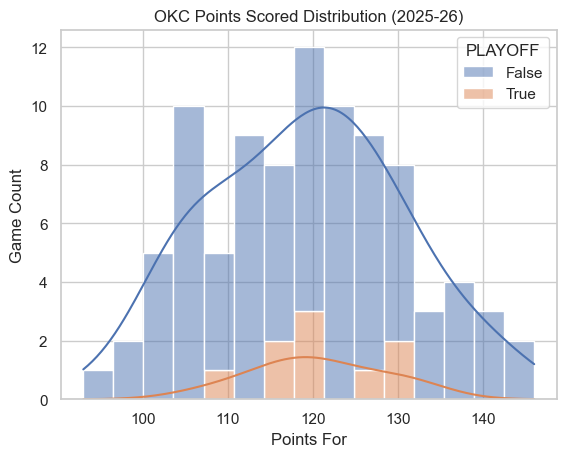

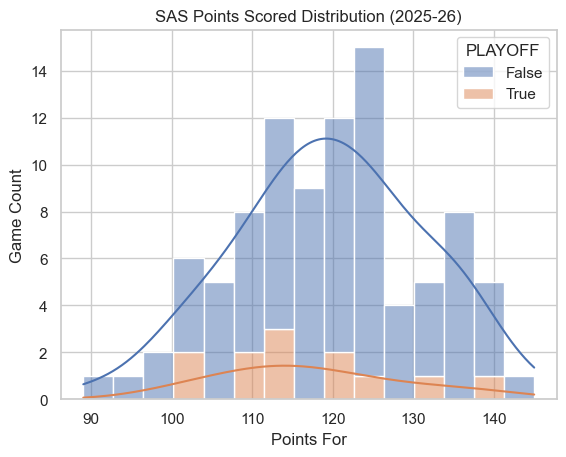

In [28]:
sns.set_theme(style="whitegrid")

# OKC Point distribution
sns.histplot(data=okc_data, x='PTS', hue = 'PLAYOFF', multiple = "stack", bins=15, kde=True, color='blue')

plt.title('OKC Points Scored Distribution (2025-26)')
plt.xlabel('Points For')
plt.ylabel('Game Count')
plt.show()

# SAS Point distribution
sns.histplot(data=sas_data, x='PTS', hue = 'PLAYOFF', multiple = "stack", bins=15, kde=True, color='blue')

plt.title('SAS Points Scored Distribution (2025-26)')
plt.xlabel('Points For')
plt.ylabel('Game Count')
plt.show()

In [30]:
def plot_recent_form(team_df, team_name):
    plt.figure(figsize=(12, 5))

    # Plot Points Scored
    sns.lineplot(
        x=team_df.index, 
        y=team_df['PTS'], 
        marker='o', 
        linewidth=2, 
        label='Points Scored (Offense)', 
        color='blue'
    )

    # Plot Points Conceded
    sns.lineplot(
        x=team_df.index, 
        y=team_df['POINTS_AGAINST'], 
        marker='o', 
        linewidth=2, 
        label='Points Against (Defense)', 
        color='red'
    )

    plt.title(f'{team_name} Recent Form: Offense vs. Defense (Last 15 Games)')
    plt.xlabel('Game Date')
    plt.ylabel('Points')
    plt.legend()

    plt.show()

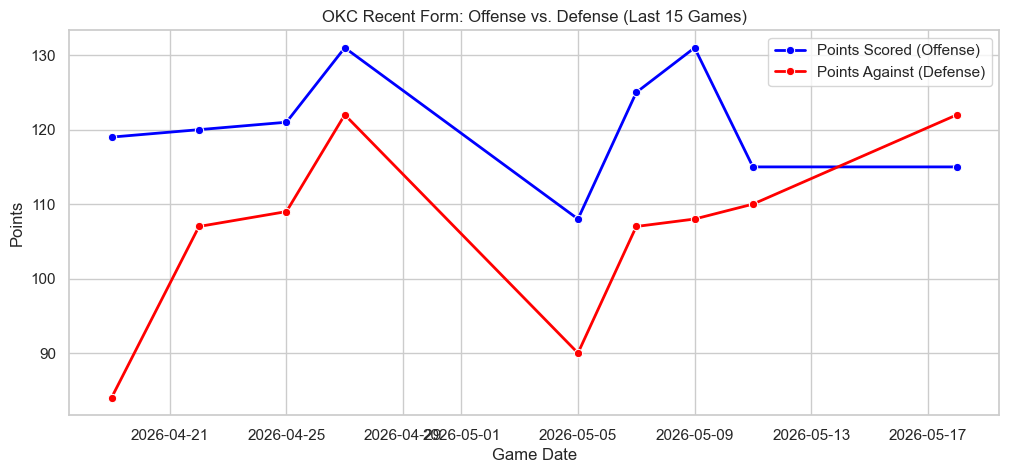

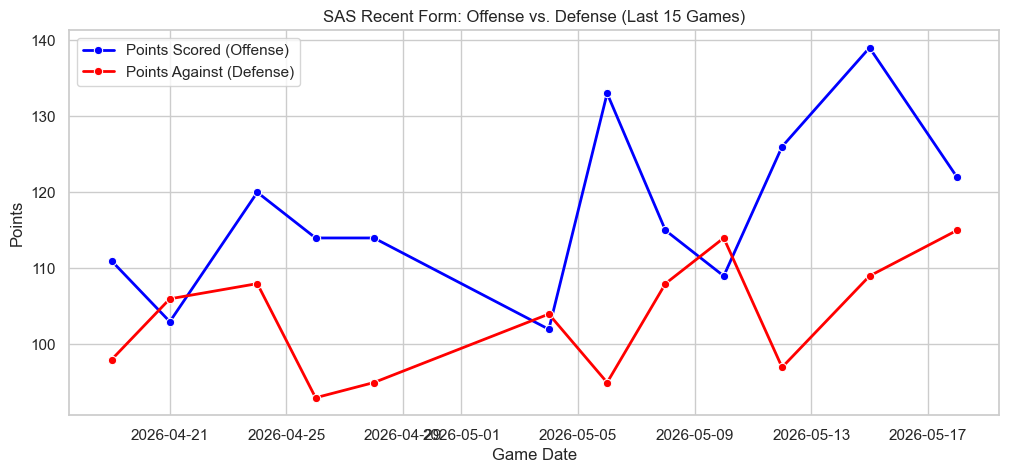

In [32]:
#Check Recent form of both teams: Last 15 games
okc_recent_form = okc_data[okc_data['PLAYOFF'] == 1]
sas_recent_form = sas_data[sas_data['PLAYOFF'] == 1]

plot_recent_form(okc_recent_form, "OKC")
plot_recent_form(sas_recent_form, "SAS")

In [22]:
# Head to Head data
h2h = okc_data[okc_data['MATCHUP'].str.contains('SAS')]

print("--- OKC vs SAS Head-to-Head ---")
print(h2h[['MATCHUP', 'WL', 'PTS', 'POINTS_AGAINST', 'PLUS_MINUS']])

--- OKC vs SAS Head-to-Head ---
                MATCHUP WL  PTS  POINTS_AGAINST  PLUS_MINUS
GAME_DATE                                                  
2025-12-13    OKC @ SAS  L  109           111.0        -2.0
2025-12-23    OKC @ SAS  L  110           130.0       -20.0
2025-12-25  OKC vs. SAS  L  102           117.0       -15.0
2026-01-13  OKC vs. SAS  W  119            98.0        21.0
2026-02-04    OKC @ SAS  L  106           116.0       -10.0
2026-05-18  OKC vs. SAS  L  115           122.0        -7.0
